# 02 - LSTM walkthrough, one stage per cell

The whole point of this notebook is that it **contains no logic of its own**: every
stage calls the same `src/` module the command-line pipeline calls. What it adds is
visibility - you can see the numbers at each step instead of trusting the pipeline.

Stages: split -> scale -> window -> model -> fit -> forecast -> evaluate -> plot.

This walks through the **price-level** target only. The full pipeline
(`python run_pipeline.py`) trains all three targets -- price, price change and log
return -- and reports every one of them against the naive baseline, plus a diagnosis
when a network collapses to an effectively constant output.

Training is capped by the `LSTM_EPOCHS` environment variable; the default ceiling is
100 epochs with early stopping, which is what the pipeline uses.

## 0. Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config, plots
from src.data_loader import load_prices
from src.evaluate import compare_to_baseline, format_table, naive_persistence
from src.model import build_lstm, compile_model
from src.preprocessing import (
    build_test_windows,
    chronological_split,
    fit_scaler,
    fraction_outside_training_range,
    inverse_scale,
    make_training_windows,
    scale,
)
from src.train import seed_everything, train_model

config.ensure_directories()
seed_everything(config.SEED)

print(f'project root : {PROJECT_ROOT}')
print(f'seed         : {config.SEED}')
print(f'window       : {config.WINDOW_SIZE} trading days')
print(f'epoch ceiling: {config.EPOCHS}')
print(f'batch size   : {config.BATCH_SIZE}')


project root : C:\Users\car info\Desktop\proj git\google stock price prediction with RNN and LSTM
seed         : 42
window       : 60 trading days
epoch ceiling: 3
batch size   : 32


## 1. Load and split chronologically

The split is positional. There is no shuffling call anywhere in `src/`, and a test in
`tests/test_preprocessing.py` fails the build if one is ever added back.

In [2]:
prices = load_prices(config.DATA_PATH, config.TARGET_COLUMN)
split = chronological_split(prices.frame, config.TEST_FRACTION)

train_dates = split.train_frame[config.DATE_COLUMN]
test_dates = split.test_frame[config.DATE_COLUMN]

print(prices.describe())
print(f'train : {train_dates.iloc[0].date()} -> {train_dates.iloc[-1].date()}  ({split.train_size} rows)')
print(f'test  : {test_dates.iloc[0].date()} -> {test_dates.iloc[-1].date()}  ({split.test_size} rows)')
print(f'gap between the slices: {(test_dates.iloc[0] - train_dates.iloc[-1]).days} calendar days')

Close: 4431 rows, 2004-08-19 -> 2022-03-24, min 50.06, max 2996.77
train : 2004-08-19 -> 2020-06-19  (3987 rows)
test  : 2020-06-22 -> 2022-03-24  (444 rows)
gap between the slices: 3 calendar days


## 2. Scale - fitted on the training slice only

The original notebook fitted its `MinMaxScaler` on the training rows of a *shuffled*
split, which smuggled test-period prices into the training range. Here the scaler only
ever sees training prices.

The honest consequence: under a chronological split the test period can trade above
anything seen in training, so scaled test inputs may exceed 1.0. That is a real
forecasting situation, and the next cell measures it rather than hiding it.

In [3]:
train_prices = split.train_frame[config.TARGET_COLUMN].to_numpy(dtype=float)
test_prices = split.test_frame[config.TARGET_COLUMN].to_numpy(dtype=float)

scaler = fit_scaler(train_prices, config.SCALER_KIND_BY_TARGET[config.PRICE_TARGET])
scaled_train_prices = scale(scaler, train_prices)
scaled_test_prices = scale(scaler, test_prices)

outside = fraction_outside_training_range(scaler, test_prices)

print(f'scaler fitted on : {train_prices.min():.2f} .. {train_prices.max():.2f}  (train only)')
print(f'scaled train     : {scaled_train_prices.min():.3f} .. {scaled_train_prices.max():.3f}')
print(f'scaled test      : {scaled_test_prices.min():.3f} .. {scaled_test_prices.max():.3f}')
print(f'test values above 1.0: {outside * 100:.1f}%  of {test_prices.size} days')
print(f'largest test price    : {test_prices.max():.2f}')

scaler fitted on : 50.06 .. 1524.87  (train only)
scaled train     : 0.000 .. 1.000
scaled test      : 0.890 .. 1.998
test values above 1.0: 87.4%  of 444 days
largest test price    : 2996.77


## 3. Window - 60 consecutive trading days in, the next day out

In [4]:
x_train, y_train = make_training_windows(scaled_train_prices, config.WINDOW_SIZE)

print(f'x_train shape : {x_train.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'derived from data: {len(scaled_train_prices)} - {config.WINDOW_SIZE} = {x_train.shape[0]} samples')
print()
print('window 0 covers these dates:')
print([str(date.date()) for date in train_dates.iloc[: config.WINDOW_SIZE]])
print(f'target of window 0 is {y_train[0]:.6f} (scaled), matching row {config.WINDOW_SIZE}')

x_train shape : (3927, 60, 1)
y_train shape : (3927,)
derived from data: 3987 - 60 = 3927 samples

window 0 covers these dates:
['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24', '2004-08-25', '2004-08-26', '2004-08-27', '2004-08-30', '2004-08-31', '2004-09-01', '2004-09-02', '2004-09-03', '2004-09-07', '2004-09-08', '2004-09-09', '2004-09-10', '2004-09-13', '2004-09-14', '2004-09-15', '2004-09-16', '2004-09-17', '2004-09-20', '2004-09-21', '2004-09-22', '2004-09-23', '2004-09-24', '2004-09-27', '2004-09-28', '2004-09-29', '2004-09-30', '2004-10-01', '2004-10-04', '2004-10-05', '2004-10-06', '2004-10-07', '2004-10-08', '2004-10-11', '2004-10-12', '2004-10-13', '2004-10-14', '2004-10-15', '2004-10-18', '2004-10-19', '2004-10-20', '2004-10-21', '2004-10-22', '2004-10-25', '2004-10-26', '2004-10-27', '2004-10-28', '2004-10-29', '2004-11-01', '2004-11-02', '2004-11-03', '2004-11-04', '2004-11-05', '2004-11-08', '2004-11-09', '2004-11-10', '2004-11-11']
target of window 0 is 0.027825 

In [5]:
# The check that would have caught the original bug immediately.
correlation = float(np.corrcoef(x_train[:, -1, 0], y_train)[0, 1])
print(f'corr(most recent value in window, next value) = {correlation:+.4f}')
print('the original notebook measured -0.0248 on its shuffled windows')

corr(most recent value in window, next value) = +0.9995
the original notebook measured -0.0248 on its shuffled windows


## 4. The model

Four stacked LSTMs of 60/60/80/120 units with dropout between them, exactly the
topology of the original notebook. One thing is corrected: the cell output
activation is Keras' default `tanh`, not the `relu` the notebook passed. `relu`
inside a recurrence is unbounded and non-standard; it is still selectable through
`config.CELL_ACTIVATION` so the two can be measured rather than argued about.

In [6]:
model = build_lstm(
    window=config.WINDOW_SIZE,
    units=config.HIDDEN_UNITS,
    dropout=config.DROPOUT_RATE,
    cell_activation=config.CELL_ACTIVATION,
)
compile_model(model)
model.summary()


Model: "googl_lstm"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1_60 (LSTM)            (None, 60, 60)            14880     
                                                                 
 dropout_1 (Dropout)         (None, 60, 60)            0         
                                                                 
 lstm_2_60 (LSTM)            (None, 60, 60)            29040     
                                                                 
 dropout_2 (Dropout)         (None, 60, 60)            0         
                                                                 
 lstm_3_80 (LSTM)            (None, 60, 80)            45120     
                                                                 
 dropout_3 (Dropout)         (None, 60, 80)            0         
                                                                 
 lstm_4_120 (LSTM)           (None, 120)               

## 5. Fit

Validation is the **tail** of the training period, not a random sample: a random
validation split would leak future prices into the early-stopping decision.

This is the slow cell. The epoch ceiling comes from `config.EPOCHS` (100 by default,
overridable with the `LSTM_EPOCHS` environment variable) and training stops early when
validation loss stops improving.

In [7]:
training_arguments = {
    'validation_fraction': config.VALIDATION_FRACTION,
    'epochs': config.EPOCHS,
    'batch_size': config.BATCH_SIZE,
    'patience': config.PATIENCE,
    'cell_activation': config.CELL_ACTIVATION,
    'hidden_units': config.HIDDEN_UNITS,
    'dropout': config.DROPOUT_RATE,
    'window': config.WINDOW_SIZE,
}

trained_model, history, (x_val, y_val) = train_model(
    inputs=x_train,
    targets=y_train,
    model_path=config.model_path_for(config.PRICE_TARGET),
    verbose=1,
    **training_arguments,
)

print()
print(f'epochs run          : {len(history.history["loss"])} of a ceiling of {config.EPOCHS}')
print(f'final train loss    : {history.history["loss"][-1]:.6f}  (scaled MSE)')
print(f'best validation loss: {min(history.history["val_loss"]):.6f}')
print(f'validation samples  : {len(x_val)}  (chronological tail of train)')

Epoch 1/3

111/111 [==============================] - 38s 202ms/step - loss: 0.0037 - val_loss: 0.0063
Epoch 2/3
111/111 [==============================] - 22s 194ms/step - loss: 0.0012 - val_loss: 0.0035
Epoch 3/3
111/111 [==============================] - 23s 205ms/step - loss: 8.1462e-04 - val_loss: 0.0055

epochs run          : 3 of a ceiling of 3
final train loss    : 0.000815  (scaled MSE)
best validation loss: 0.003505
validation samples  : 392  (chronological tail of train)


## 6. One-step-ahead forecasts for the test period

The test inputs are built from one continuous history: the 60 days before the split
plus every test day. Forecast `i` therefore belongs to test day `i`, which is the
alignment the original notebook lost when it compared two shuffled frames row by row.

In [8]:
window = config.WINDOW_SIZE
all_prices = prices.values
split_index = split.split_index
test_days = split.test_size

context = all_prices[split_index - window : split_index + test_days]
x_test = build_test_windows(scale(scaler, context), window, test_days)

predicted_prices = inverse_scale(scaler, trained_model.predict(x_test, verbose=0).ravel())
reference_prices = all_prices[split_index - 1 : split_index + test_days - 1]
baseline_prices = naive_persistence(reference_prices)

forecasts = pd.DataFrame(
    {
        config.DATE_COLUMN: test_dates.to_numpy(),
        'previous_close': reference_prices,
        'predicted': predicted_prices,
        'actual': test_prices,
        'naive_baseline': baseline_prices,
    }
)
forecasts.head(10)

,Date,previous_close,predicted,actual,naive_baseline
0,2020-06-22,1424.640015,1323.492616,1450.660034,1424.640015
1,2020-06-23,1450.660034,1324.999673,1463.979980,1450.660034
2,2020-06-24,1463.979980,1326.389113,1432.699951,1463.979980
3,2020-06-25,1432.699951,1327.679043,1441.099976,1432.699951
4,2020-06-26,1441.099976,1328.878957,1362.540039,1441.099976
5,2020-06-29,1362.540039,1329.827549,1397.170044,1362.540039
6,2020-06-30,1397.170044,1330.415199,1418.050049,1397.170044
7,2020-07-01,1418.050049,1330.623976,1442.000000,1418.050049
8,2020-07-02,1442.000000,1330.536070,1469.930054,1442.000000
9,2020-07-06,1469.930054,1330.323865,1499.650024,1469.930054


In [9]:
print(f'x_test shape            : {x_test.shape}')
print(f'predicted std           : ${np.std(predicted_prices):.2f}')
print(f'actual std              : ${np.std(test_prices):.2f}')
print(f'corr(predicted, actual) : {np.corrcoef(predicted_prices, test_prices)[0, 1]:+.4f}')
print()
print('the broken notebook produced predictions spanning $5.81 across its whole test set')

x_test shape            : (444, 60, 1)
predicted std           : $294.72
actual std              : $520.30
corr(predicted, actual) : +0.9842

the broken notebook produced predictions spanning $5.81 across its whole test set


## 7. Metrics, always beside the naive baseline

`naive_baseline` is tomorrows price = todays price. A stock price is heavily
autocorrelated, so this baseline is strong, and a model that does not beat it has not
added anything. Directional accuracy asks the harder question: did the forecast get
the sign of the next-day move right?

In [10]:
comparison = compare_to_baseline(
    test_prices, predicted_prices, baseline_prices, reference_prices
)
print(format_table(comparison, 'model vs naive persistence, price target'))

model vs naive persistence, price target
  forecasts scored: 444

  metric                        model naive_baseline          delta
  -----------------------------------------------------------------
  rmse                       496.1112        38.6486       457.4626
  mae                        436.6308        27.9429       408.6878
  mape                        17.9923         1.2736        16.7186
  r2                           0.0908         0.9945        -0.9037
  direction_accuracy           0.4482            n/a            n/a

  RMSE        : model does NOT beat the naive baseline
  direction   : the naive baseline makes no directional call (it predicts
                exactly the previous price), so there is nothing to compare
                against; the model scored 0.4482
  base rate   : 0.5586 of these days closed above the previous close,
                so a forecast that always answers 'up' scores exactly that.
                Directional accuracy is only skill to the

## 8. Figures, on the real date axis

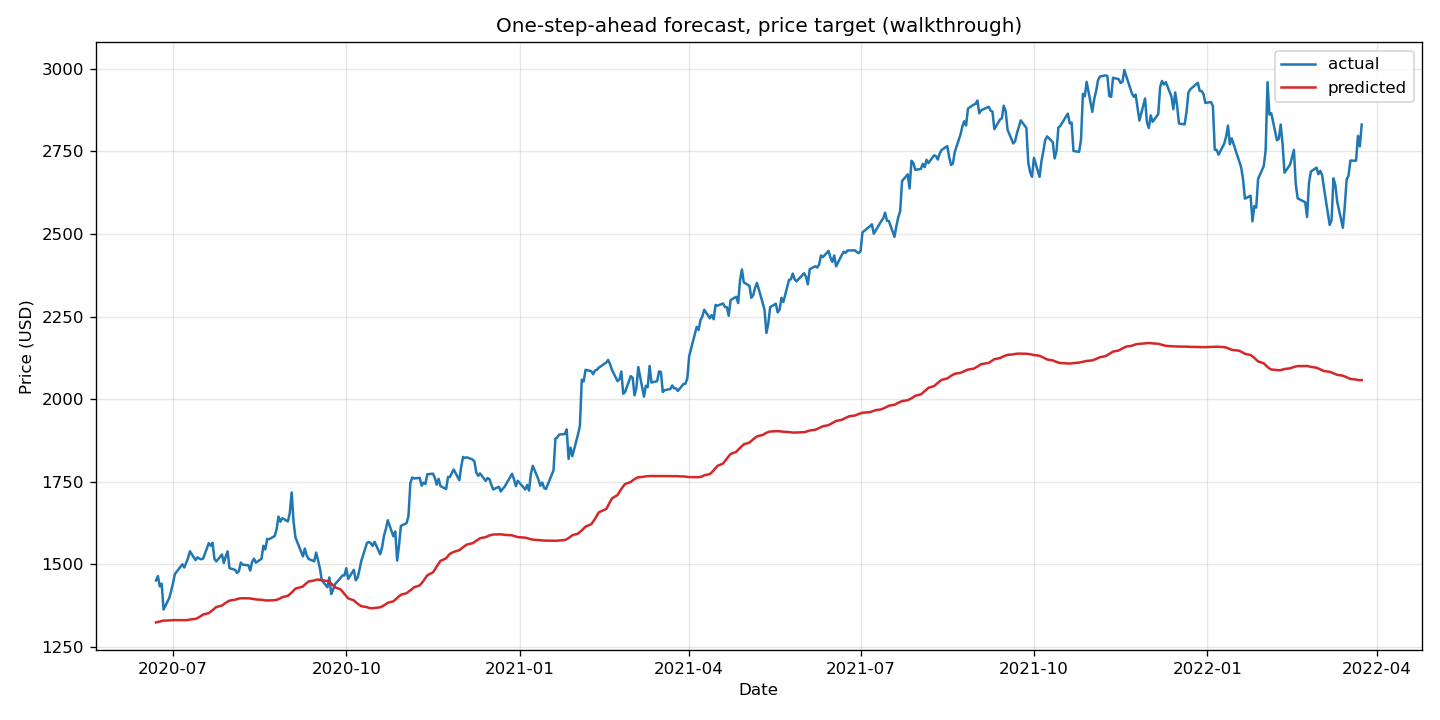

In [11]:
prediction_png = config.FIGURES_DIR / 'walkthrough_prediction_vs_actual.png'
plots.plot_prediction_vs_actual(
    test_dates, test_prices, predicted_prices, prediction_png,
    'One-step-ahead forecast, price target (walkthrough)',
)
display(Image(filename=str(prediction_png)))

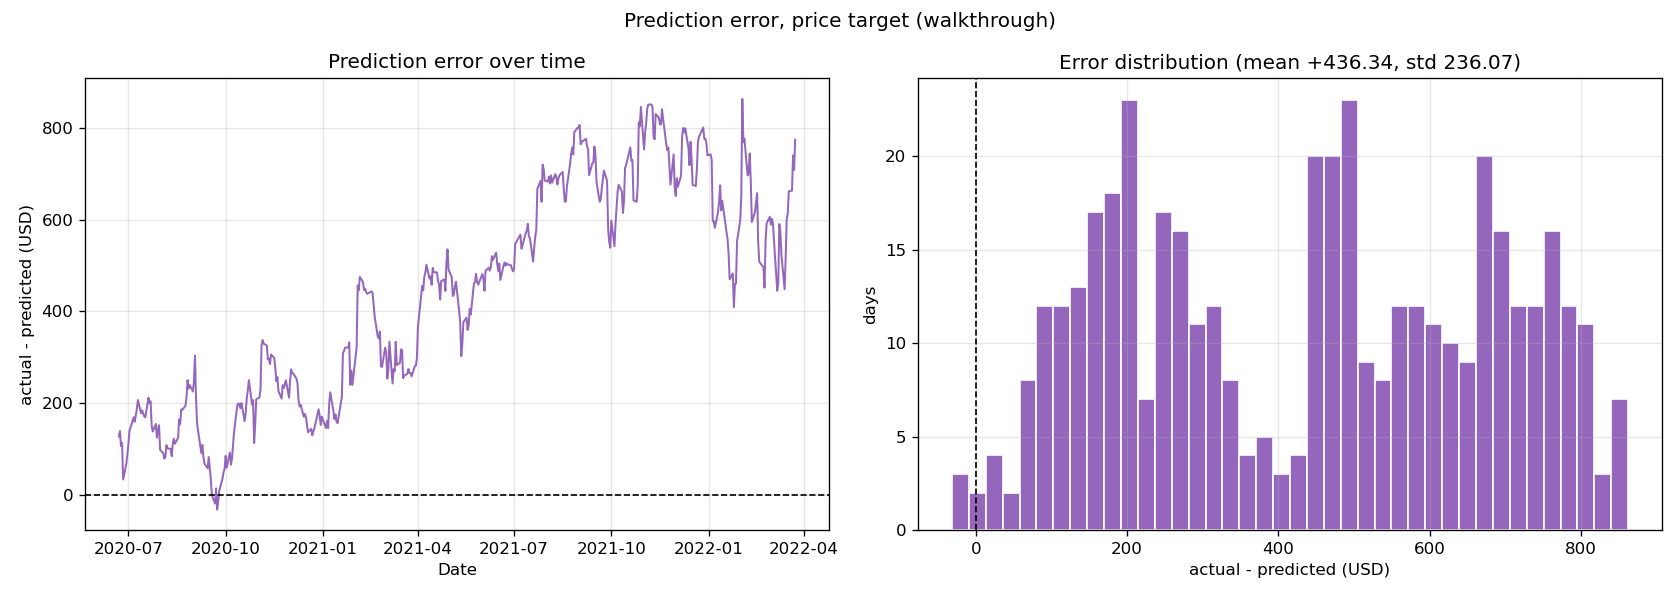

In [12]:
residual_png = config.FIGURES_DIR / 'walkthrough_residuals.png'
plots.plot_residuals(
    test_dates, test_prices, predicted_prices, residual_png,
    'Prediction error, price target (walkthrough)',
)
display(Image(filename=str(residual_png)))

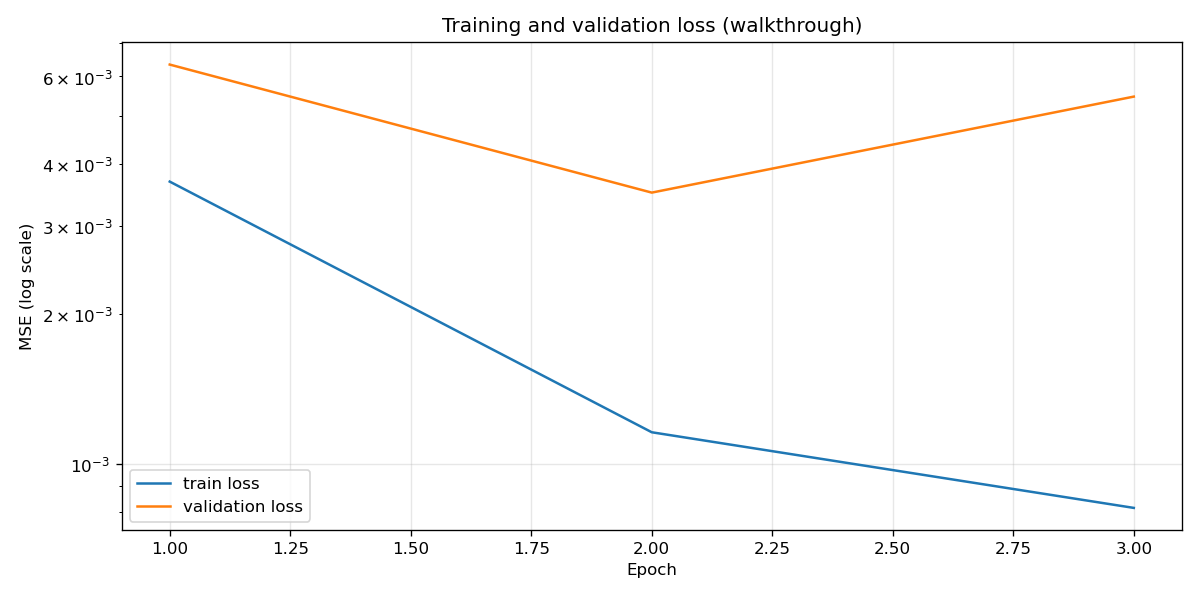

In [13]:
history_png = config.FIGURES_DIR / 'walkthrough_training_history.png'
plots.plot_training_history(
    history, history_png, 'Training and validation loss (walkthrough)'
)
display(Image(filename=str(history_png)))

## 9. Conclusion

The forecasts vary with the price level and track the test curve, which is the
symptom the original notebook failed: it output the same number every day because its
shuffled windows carried no information about the target.

The numbers stored in this file come from whatever epoch ceiling `LSTM_EPOCHS` set when
it was last executed -- the setup cell prints it, and the stored output above shows
`epoch ceiling: 3`. `README.md` reports the full run at the 100-epoch ceiling, so its
price-target metrics are worse than these smoke-run figures, not better.

The metric table above is the part that matters. Read it in `README.md` alongside the
price-change and log-return targets, and treat the baseline column as the bar the
model has to clear. Note that the log-return model's directional accuracy equals the
up-day share of the test period exactly, which is the base rate, not evidence of skill.

To reproduce everything (three targets, every figure, every checkpoint) from a clean
shell:

```
python run_pipeline.py          # or: python -m src.run_pipeline
python -m pytest tests/ -v
```